# 11. Soporte de Decision para Pipeline Definitivo Thoracolumbar - Colab

Este notebook consolida la evidencia de los notebooks 03, 05, 06 y 07 para
responder una pregunta de proyecto:

> Con los resultados actuales, cual es la mejor configuracion operativa para
> declarar un pipeline casi definitivo sin cambiar la estrategia general?

## Lo que haremos

1. comparar globalmente las variantes ya medidas
2. revisar el comportamiento por muestra
3. evaluar politicas candidatas sencillas y disponibles en inferencia
4. exportar una recomendacion tecnica clara

## Importante

Las metricas `macro_dice_fg` ya probadas siguen siendo la referencia principal.
Las politicas nuevas que se prueban aqui son exploratorias y se evalúan con
proxies basados en sets de etiquetas, no reemplazan una validacion completa a
pixel.

## 0. Preparacion de Colab

In [17]:
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except Exception as exc:
    print('No se detecto entorno Colab o Drive ya estaba montado:', exc)

# Cambia esta ruta solo si la carpeta del proyecto esta en otro lugar de tu Drive.
PROJECT_ROOT = Path("/content/drive/MyDrive/DataRadriografias")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'No existe la carpeta: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
print('Working directory:', Path.cwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/DataRadriografias


## 1. Librerias y resolucion de archivos

In [18]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'analysis_outputs' / 'definitive_pipeline_decision_support_thoracolumbar'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def resolve_existing(*relative_candidates: str) -> Path:
    search_roots = [ROOT, ROOT / 'reports']
    for base in search_roots:
        for rel in relative_candidates:
            candidate = base / rel
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f'No se encontro ninguno de estos archivos: {relative_candidates}')


MANIFEST_PATH = resolve_existing('analysis_outputs/training_manifest_thoracolumbar.csv')
POST_V2_SUMMARY_PATH = resolve_existing(
    'analysis_outputs/thoracolumbar_postprocess_anatomical_v2_explained/postprocess_v2_experiment_summary.csv'
)
RANGE_SUMMARY_PATH = resolve_existing(
    'analysis_outputs/visible_range_estimator_thoracolumbar_explained/visible_range_experiment_summary.csv'
)
LAST_SUMMARY_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_experiment_summary.csv'
)
POST_V2_COMPARE_PATH = resolve_existing(
    'analysis_outputs/thoracolumbar_postprocess_anatomical_v2_explained/postprocess_v2_per_sample_compare.csv'
)
LAST_COMPARE_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_per_sample_compare.csv'
)
LAST_TEST_PRED_PATH = resolve_existing(
    'analysis_outputs/last_visible_estimator_thoracolumbar_explained/last_visible_test_predictions.csv'
)
INFERENCE_PER_SAMPLE_PATH = resolve_existing(
    'analysis_outputs/thoracolumbar_inference_analysis_explained/inference_per_sample_summary.csv'
)

print('OUTPUT_DIR:', OUTPUT_DIR)

OUTPUT_DIR: /content/drive/MyDrive/DataRadriografias/analysis_outputs/definitive_pipeline_decision_support_thoracolumbar


## 2. Carga de resultados ya existentes

In [19]:
manifest_df = pd.read_csv(MANIFEST_PATH)
post_v2_summary_df = pd.read_csv(POST_V2_SUMMARY_PATH)
range_summary_df = pd.read_csv(RANGE_SUMMARY_PATH)
last_summary_df = pd.read_csv(LAST_SUMMARY_PATH)
post_v2_compare_df = pd.read_csv(POST_V2_COMPARE_PATH)
last_compare_df = pd.read_csv(LAST_COMPARE_PATH)
last_test_pred_df = pd.read_csv(LAST_TEST_PRED_PATH)
inference_per_sample_df = pd.read_csv(INFERENCE_PER_SAMPLE_PATH)

print('post_v2_summary_df:', post_v2_summary_df.shape)
print('range_summary_df:', range_summary_df.shape)
print('last_summary_df:', last_summary_df.shape)
print('post_v2_compare_df:', post_v2_compare_df.shape)
print('last_compare_df:', last_compare_df.shape)
print('last_test_pred_df:', last_test_pred_df.shape)
print('inference_per_sample_df:', inference_per_sample_df.shape)

post_v2_summary_df: (14, 2)
range_summary_df: (12, 2)
last_summary_df: (13, 2)
post_v2_compare_df: (45, 14)
last_compare_df: (45, 21)
last_test_pred_df: (45, 12)
inference_per_sample_df: (45, 15)


## 3. Tabla global de variantes ya probadas

Esta es la comparacion fuerte del proyecto porque usa metricas pixel a pixel ya
producidas por los notebooks base.

In [20]:
global_compare_rows = [
    {
        'variant': 'raw_multiclass',
        'macro_dice_fg': float(last_summary_df.loc[last_summary_df['metric'] == 'raw_macro_dice_fg', 'value'].iloc[0]),
        'source': '07/last_visible_experiment_summary',
        'status': 'reference',
    },
    {
        'variant': 'postprocess_v2',
        'macro_dice_fg': float(post_v2_summary_df.loc[post_v2_summary_df['metric'] == 'post_v2_macro_dice_fg', 'value'].iloc[0]),
        'source': '05/postprocess_v2_experiment_summary',
        'status': 'optional',
    },
    {
        'variant': 'visible_range_pred_clip',
        'macro_dice_fg': float(range_summary_df.loc[range_summary_df['metric'] == 'pred_clip_macro_dice_fg', 'value'].iloc[0]),
        'source': '06/visible_range_experiment_summary',
        'status': 'improved',
    },
    {
        'variant': 'last_visible_pred_clip',
        'macro_dice_fg': float(last_summary_df.loc[last_summary_df['metric'] == 'last_pred_clip_macro_dice_fg', 'value'].iloc[0]),
        'source': '07/last_visible_experiment_summary',
        'status': 'best_proven',
    },
    {
        'variant': 'oracle_clip',
        'macro_dice_fg': float(last_summary_df.loc[last_summary_df['metric'] == 'oracle_macro_dice_fg', 'value'].iloc[0]),
        'source': '07/last_visible_experiment_summary',
        'status': 'upper_bound',
    },
]
global_compare_df = pd.DataFrame(global_compare_rows).sort_values('macro_dice_fg', ascending=False).reset_index(drop=True)
display(global_compare_df)

,variant,macro_dice_fg,source,status
0,oracle_clip,0.331591,07/last_visible_experiment_summary,upper_bound
1,last_visible_pred_clip,0.304899,07/last_visible_experiment_summary,best_proven
2,postprocess_v2,0.299105,05/postprocess_v2_experiment_summary,optional
3,raw_multiclass,0.296726,07/last_visible_experiment_summary,reference
4,visible_range_pred_clip,0.296726,06/visible_range_experiment_summary,improved


## 4. Union por muestra para analizar el trade-off real

Aqui unimos la vista del multiclase crudo, el postproceso v2 y el clipping por
`last_visible`.

In [21]:
def coalesce_column(df: pd.DataFrame, preferred: str, candidates: list[str]) -> pd.DataFrame:
    available = [col for col in candidates if col in df.columns]
    if preferred in df.columns and preferred not in available:
        available = [preferred] + available
    if not available:
        return df

    series = df[available[0]].copy()
    for col in available[1:]:
        series = series.fillna(df[col])

    df[preferred] = series
    return df


def count_labels_from_text(value: object) -> int:
    if pd.isna(value):
        return 0
    items = [item.strip() for item in str(value).split(',') if item.strip()]
    return len(items)


compare_df = (
    last_compare_df
    .merge(
        post_v2_compare_df[
            [
                'unique_sample_id', 'post_v2_labels', 'post_missing_count',
                'post_extra_count', 'post_num_labels'
            ]
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        last_test_pred_df[
            ['unique_sample_id', 'first_idx', 'last_true_idx', 'last_pred_idx', 'last_abs_error']
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        inference_per_sample_df[
            ['unique_sample_id', 'roi_source', 'num_gt_labels', 'num_pred_labels']
        ],
        on='unique_sample_id',
        how='left',
    )
    .merge(
        manifest_df[
            ['unique_sample_id', 'split', 'image', 'num_visible_target_vertebrae', 'total_internal_missing_count']
        ].rename(columns={'split': 'manifest_split', 'image': 'manifest_image'}),
        on='unique_sample_id',
        how='left',
    )
)

compare_df = coalesce_column(compare_df, 'split', ['split', 'split_x', 'split_y', 'manifest_split'])
compare_df = coalesce_column(compare_df, 'image', ['image', 'image_x', 'image_y', 'manifest_image'])

if 'split' not in compare_df.columns:
    raise KeyError(
        f"No fue posible reconstruir la columna 'split'. Columnas disponibles: {sorted(compare_df.columns.tolist())}"
    )

if 'image' not in compare_df.columns:
    raise KeyError(
        f"No fue posible reconstruir la columna 'image'. Columnas disponibles: {sorted(compare_df.columns.tolist())}"
    )

if 'raw_num_labels' not in compare_df.columns:
    if 'raw_labels' in compare_df.columns:
        compare_df['raw_num_labels'] = compare_df['raw_labels'].apply(count_labels_from_text)
    elif 'num_pred_labels' in compare_df.columns:
        compare_df['raw_num_labels'] = pd.to_numeric(compare_df['num_pred_labels'], errors='coerce').fillna(0)
    else:
        compare_df['raw_num_labels'] = 0

if 'post_num_labels' not in compare_df.columns:
    if 'post_v2_labels' in compare_df.columns:
        compare_df['post_num_labels'] = compare_df['post_v2_labels'].apply(count_labels_from_text)
    else:
        compare_df['post_num_labels'] = 0

if 'last_pred_clip_labels' not in compare_df.columns:
    compare_df['last_pred_clip_labels'] = ''

compare_df['is_partial_case'] = compare_df['num_visible_target_vertebrae'] < 17
compare_df['is_scoliosis_case'] = compare_df['split'].astype(str).str.lower().eq('scoliosis')
compare_df['predicted_trim_levels'] = (
    compare_df['raw_num_labels'].fillna(compare_df['num_pred_labels']).fillna(0)
    - compare_df['last_pred_clip_labels'].fillna('').apply(
        count_labels_from_text
    )
)


def label_set_dice_proxy(num_gt: float, missing: float, extra: float) -> float:
    true_positive = max(float(num_gt) - float(missing), 0.0)
    denom = (2.0 * true_positive) + float(missing) + float(extra)
    if denom <= 0:
        return 1.0
    return (2.0 * true_positive) / denom


compare_df['raw_labelset_dice_proxy'] = compare_df.apply(
    lambda row: label_set_dice_proxy(row['num_gt_labels'], row['raw_missing_count'], row['raw_extra_count']),
    axis=1,
)
compare_df['post_v2_labelset_dice_proxy'] = compare_df.apply(
    lambda row: label_set_dice_proxy(row['num_gt_labels'], row['post_missing_count'], row['post_extra_count']),
    axis=1,
)
compare_df['last_labelset_dice_proxy'] = compare_df.apply(
    lambda row: label_set_dice_proxy(row['num_gt_labels'], row['last_missing_count'], row['last_extra_count']),
    axis=1,
)

display(compare_df.head())

,unique_sample_id,split,image,gt_first_label,gt_last_label,last_pred_label,gt_labels,raw_labels,oracle_labels,last_pred_clip_labels,...,manifest_image,num_visible_target_vertebrae,total_internal_missing_count,raw_num_labels,is_partial_case,is_scoliosis_case,predicted_trim_levels,raw_labelset_dice_proxy,post_v2_labelset_dice_proxy,last_labelset_dice_proxy
0,Normal__N_4.jpg,Normal,N_4.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,N_4.jpg,17,0,17,False,False,0,1.0,1.0,1.0
1,Normal__N_6.jpg,Normal,N_6.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,N_6.jpg,17,0,17,False,False,0,1.0,1.0,1.0
2,Normal__N_8.jpg,Normal,N_8.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,N_8.jpg,17,0,17,False,False,0,1.0,1.0,1.0
3,Normal__N_15.jpg,Normal,N_15.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,N_15.jpg,17,0,17,False,False,0,1.0,1.0,1.0
4,Normal__N_18.jpg,Normal,N_18.jpg,T1,L5,L5,"T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...","T1, T2, T3, T4, T5, T6, T7, T8, T9, T10, T11, ...",...,N_18.jpg,17,0,17,False,False,0,1.0,1.0,1.0


## 5. Politicas candidatas simples y disponibles en inferencia

Buscamos reglas que no dependan del ground truth, sino de cosas que el pipeline ya
conoce en inferencia, por ejemplo cuanto recorta la prediccion final.

In [22]:
policy_rows = []


def summarize_policy(df: pd.DataFrame, choice_col: str, policy_name: str) -> dict:
    selected_missing = np.where(df[choice_col] == 'last', df['last_missing_count'], df['raw_missing_count'])
    selected_extra = np.where(df[choice_col] == 'last', df['last_extra_count'], df['raw_extra_count'])
    selected_proxy = np.where(df[choice_col] == 'last', df['last_labelset_dice_proxy'], df['raw_labelset_dice_proxy'])
    selected_uses_last = np.where(df[choice_col] == 'last', 1, 0)
    clean_improvement = (
        (selected_extra < df['raw_extra_count'])
        & (selected_missing <= df['raw_missing_count'])
    ).mean()
    harm_rate = (
        (selected_missing > df['raw_missing_count'])
    ).mean()
    return {
        'policy_name': policy_name,
        'mean_proxy_dice': float(np.mean(selected_proxy)),
        'mean_missing_count': float(np.mean(selected_missing)),
        'mean_extra_count': float(np.mean(selected_extra)),
        'fraction_using_last_clip': float(np.mean(selected_uses_last)),
        'clean_improvement_rate': float(clean_improvement),
        'harm_rate': float(harm_rate),
    }


base_policy_df = compare_df.copy()
base_policy_df['policy_raw'] = 'raw'
policy_rows.append(summarize_policy(base_policy_df, 'policy_raw', 'raw_only'))

base_policy_df['policy_last'] = 'last'
policy_rows.append(summarize_policy(base_policy_df, 'policy_last', 'last_clip_always'))

for min_trim in [1, 2, 3, 4]:
    work = compare_df.copy()
    work[f'policy_trim_ge_{min_trim}'] = np.where(
        work['predicted_trim_levels'].fillna(0) >= min_trim,
        'last',
        'raw',
    )
    policy_rows.append(
        summarize_policy(work, f'policy_trim_ge_{min_trim}', f'use_last_if_trim_ge_{min_trim}')
    )

for min_trim_normal in [2, 3]:
    work = compare_df.copy()
    work[f'policy_scoliosis_ge1_normal_ge{min_trim_normal}'] = np.where(
        work['is_scoliosis_case'].fillna(False),
        np.where(work['predicted_trim_levels'].fillna(0) >= 1, 'last', 'raw'),
        np.where(work['predicted_trim_levels'].fillna(0) >= min_trim_normal, 'last', 'raw'),
    )
    policy_rows.append(
        summarize_policy(
            work,
            f'policy_scoliosis_ge1_normal_ge{min_trim_normal}',
            f'use_last_if_scoliosis_trim_ge_1_else_trim_ge_{min_trim_normal}',
        )
    )

policy_compare_df = pd.DataFrame(policy_rows).sort_values(
    ['mean_proxy_dice', 'mean_extra_count'],
    ascending=[False, True]
).reset_index(drop=True)

display(policy_compare_df)

,policy_name,mean_proxy_dice,mean_missing_count,mean_extra_count,fraction_using_last_clip,clean_improvement_rate,harm_rate
0,last_clip_always,0.906497,0.488889,1.911111,1.000000,0.200000,0.155556
1,use_last_if_trim_ge_1,0.906497,0.488889,1.911111,0.355556,0.200000,0.155556
2,use_last_if_scoliosis_trim_ge_1_else_trim_ge_2,0.906497,0.488889,1.911111,0.355556,0.200000,0.155556
3,use_last_if_scoliosis_trim_ge_1_else_trim_ge_3,0.906497,0.488889,1.911111,0.355556,0.200000,0.155556
4,use_last_if_trim_ge_3,0.903161,0.466667,2.044444,0.222222,0.088889,0.133333
5,use_last_if_trim_ge_2,0.903117,0.488889,2.022222,0.244444,0.088889,0.155556
6,use_last_if_trim_ge_4,0.901309,0.466667,2.111111,0.200000,0.066667,0.133333
7,raw_only,0.886781,0.066667,3.022222,0.000000,0.000000,0.000000


## 6. Comparacion por slices para la mejor politica proxy

Esto ayuda a ver si la politica exploratoria favorece solo un tipo de imagen o si
se comporta de manera estable.

In [23]:
best_proxy_policy = policy_compare_df.iloc[0]['policy_name']
compare_df['proxy_policy_choice'] = 'raw'

if best_proxy_policy == 'last_clip_always':
    compare_df['proxy_policy_choice'] = 'last'
elif best_proxy_policy.startswith('use_last_if_trim_ge_'):
    trim_value = int(best_proxy_policy.split('_')[-1])
    compare_df['proxy_policy_choice'] = np.where(compare_df['predicted_trim_levels'].fillna(0) >= trim_value, 'last', 'raw')
elif best_proxy_policy == 'use_last_if_scoliosis_trim_ge_1_else_trim_ge_2':
    compare_df['proxy_policy_choice'] = np.where(
        compare_df['is_scoliosis_case'].fillna(False),
        np.where(compare_df['predicted_trim_levels'].fillna(0) >= 1, 'last', 'raw'),
        np.where(compare_df['predicted_trim_levels'].fillna(0) >= 2, 'last', 'raw'),
    )
elif best_proxy_policy == 'use_last_if_scoliosis_trim_ge_1_else_trim_ge_3':
    compare_df['proxy_policy_choice'] = np.where(
        compare_df['is_scoliosis_case'].fillna(False),
        np.where(compare_df['predicted_trim_levels'].fillna(0) >= 1, 'last', 'raw'),
        np.where(compare_df['predicted_trim_levels'].fillna(0) >= 3, 'last', 'raw'),
    )

slice_rows = []
slice_specs = [
    ('all_test', pd.Series([True] * len(compare_df))),
    ('partial', compare_df['is_partial_case']),
    ('full_range', ~compare_df['is_partial_case']),
    ('scoliosis', compare_df['is_scoliosis_case']),
    ('normal', ~compare_df['is_scoliosis_case']),
]

for slice_name, mask in slice_specs:
    work = compare_df.loc[mask.fillna(False)].copy()
    if work.empty:
        continue
    selected_missing = np.where(work['proxy_policy_choice'] == 'last', work['last_missing_count'], work['raw_missing_count'])
    selected_extra = np.where(work['proxy_policy_choice'] == 'last', work['last_extra_count'], work['raw_extra_count'])
    selected_proxy = np.where(work['proxy_policy_choice'] == 'last', work['last_labelset_dice_proxy'], work['raw_labelset_dice_proxy'])

    slice_rows.append({
        'slice_name': slice_name,
        'images': len(work),
        'mean_proxy_dice': float(np.mean(selected_proxy)),
        'mean_missing_count': float(np.mean(selected_missing)),
        'mean_extra_count': float(np.mean(selected_extra)),
        'fraction_using_last_clip': float(np.mean(work['proxy_policy_choice'] == 'last')),
    })

policy_slice_df = pd.DataFrame(slice_rows)
display(policy_slice_df)

,slice_name,images,mean_proxy_dice,mean_missing_count,mean_extra_count,fraction_using_last_clip
0,all_test,45,0.906497,0.488889,1.911111,1.0
1,partial,32,0.876613,0.468750,2.687500,1.0
2,full_range,13,0.980057,0.538462,0.000000,1.0
3,scoliosis,28,0.873410,0.535714,2.642857,1.0
4,normal,17,0.960993,0.411765,0.705882,1.0


## 7. Conclusiones operativas

Separamos dos niveles de decision:

- **mejor variante ya probada a pixel**: la que podemos declarar hoy con respaldo fuerte
- **mejor politica proxy exploratoria**: candidata para una validacion posterior

In [24]:
best_proven_row = global_compare_df.loc[global_compare_df['status'] == 'best_proven'].iloc[0]
best_proxy_row = policy_compare_df.iloc[0]

recommendation_df = pd.DataFrame([
    {
        'decision_type': 'best_proven_pipeline',
        'recommended_variant': best_proven_row['variant'],
        'reason': 'Es la mejor variante ya validada con macro_dice_fg sobre mascara.',
        'metric_reference': float(best_proven_row['macro_dice_fg']),
    },
    {
        'decision_type': 'best_proxy_policy',
        'recommended_variant': best_proxy_row['policy_name'],
        'reason': 'Es la mejor politica exploratoria segun proxy de set de etiquetas y trade-off missing/extra.',
        'metric_reference': float(best_proxy_row['mean_proxy_dice']),
    },
    {
        'decision_type': 'strategic_next_step',
        'recommended_variant': 'retrain_last_visible_with_refined_sampling',
        'reason': 'El mayor margen de mejora sigue estando entre last_visible_pred_clip y oracle_clip.',
        'metric_reference': float(
            global_compare_df.loc[global_compare_df['variant'] == 'oracle_clip', 'macro_dice_fg'].iloc[0]
            - best_proven_row['macro_dice_fg']
        ),
    },
])

display(recommendation_df)

,decision_type,recommended_variant,reason,metric_reference
0,best_proven_pipeline,last_visible_pred_clip,Es la mejor variante ya validada con macro_dic...,0.304899
1,best_proxy_policy,last_clip_always,Es la mejor politica exploratoria segun proxy ...,0.906497
2,strategic_next_step,retrain_last_visible_with_refined_sampling,El mayor margen de mejora sigue estando entre ...,0.026692


## 8. Visualizaciones

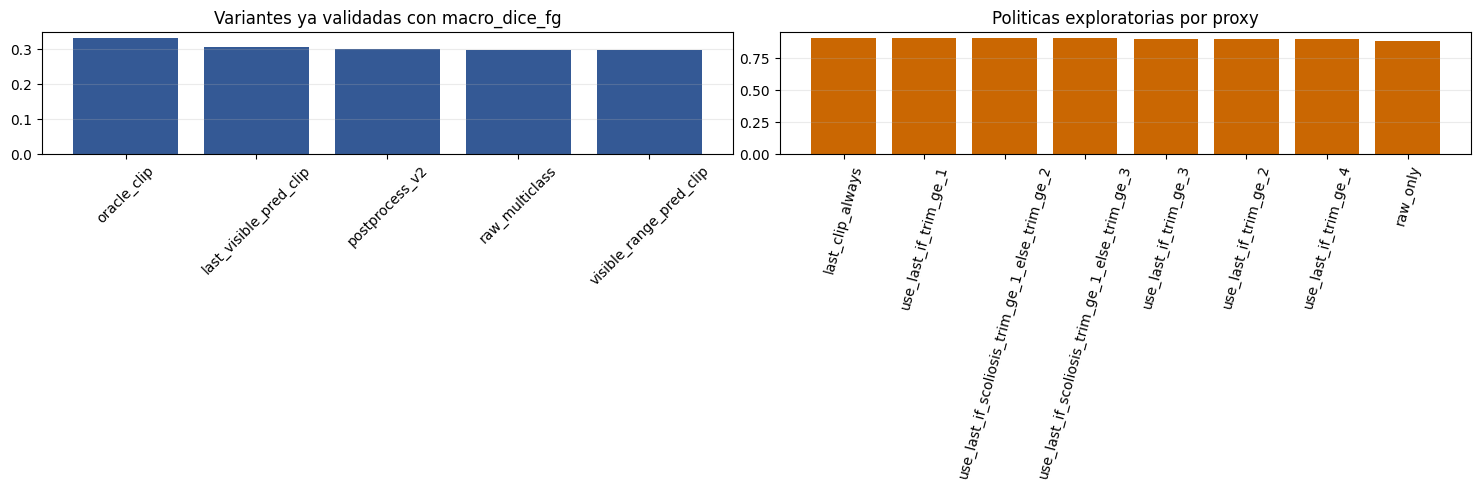

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(global_compare_df['variant'], global_compare_df['macro_dice_fg'], color='#345995')
axes[0].set_title('Variantes ya validadas con macro_dice_fg')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.25, axis='y')

axes[1].bar(policy_compare_df['policy_name'], policy_compare_df['mean_proxy_dice'], color='#ca6702')
axes[1].set_title('Politicas exploratorias por proxy')
axes[1].tick_params(axis='x', rotation=75)
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

## 9. Exportacion de tablas de decision

In [26]:
global_compare_path = OUTPUT_DIR / 'global_pipeline_compare.csv'
merged_compare_path = OUTPUT_DIR / 'per_sample_pipeline_compare.csv'
policy_compare_path = OUTPUT_DIR / 'proxy_policy_compare.csv'
policy_slice_path = OUTPUT_DIR / 'proxy_policy_slice_summary.csv'
recommendation_path = OUTPUT_DIR / 'definitive_pipeline_recommendation.csv'

global_compare_df.to_csv(global_compare_path, index=False)
compare_df.to_csv(merged_compare_path, index=False)
policy_compare_df.to_csv(policy_compare_path, index=False)
policy_slice_df.to_csv(policy_slice_path, index=False)
recommendation_df.to_csv(recommendation_path, index=False)

print('Guardado:', global_compare_path)
print('Guardado:', merged_compare_path)
print('Guardado:', policy_compare_path)
print('Guardado:', policy_slice_path)
print('Guardado:', recommendation_path)

Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/definitive_pipeline_decision_support_thoracolumbar/global_pipeline_compare.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/definitive_pipeline_decision_support_thoracolumbar/per_sample_pipeline_compare.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/definitive_pipeline_decision_support_thoracolumbar/proxy_policy_compare.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/definitive_pipeline_decision_support_thoracolumbar/proxy_policy_slice_summary.csv
Guardado: /content/drive/MyDrive/DataRadriografias/analysis_outputs/definitive_pipeline_decision_support_thoracolumbar/definitive_pipeline_recommendation.csv
